# Customer Churn Prediction Project

In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV, learning_curve, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, fbeta_score, make_scorer, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import shap
from feature_engineering import total_service_transformer, gender_binary_transformer, yes_no_transformer 


In [2]:
pd.set_option("display.max_columns", 50)

## Getting the Data from Database

In [3]:
conn = sqlite3.connect("Data/Telco_churn")

In [4]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

   name
0  Data


In [5]:
df = pd.read_sql_query("SELECT * FROM Data", conn)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploring the Dataframe

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.TotalCharges.value_counts().sort_values(ascending=False)

TotalCharges
           11
20.2       11
19.75       9
20.05       8
19.9        8
           ..
3886.45     1
1224.05     1
2310.2      1
723.4       1
6844.5      1
Name: count, Length: 6531, dtype: int64

In [9]:
df[df.TotalCharges == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Since all empty rows' `Tenure` values are 0, it means that they have not paid any amount yet. Thus I will make those values 0.

In [10]:
df.loc[df.TotalCharges == " ", "TotalCharges"] = 0

In [11]:
df[df.TotalCharges == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [12]:
df.TotalCharges = df.TotalCharges.astype(int)
# Changing TotalCharges column to integer type

In [13]:
df.drop("customerID", axis=1, inplace=True)

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.265086
std,0.368612,24.559481,30.090047,2266.790864
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.000000
50%,0.000000,29.000000,70.350000,1394.000000
75%,0.000000,55.000000,89.850000,3786.500000
max,1.000000,72.000000,118.750000,8684.000000


In [15]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(22)

## Univariate Analysis    

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


#### Categorical Variables

<Axes: xlabel='gender', ylabel='count'>

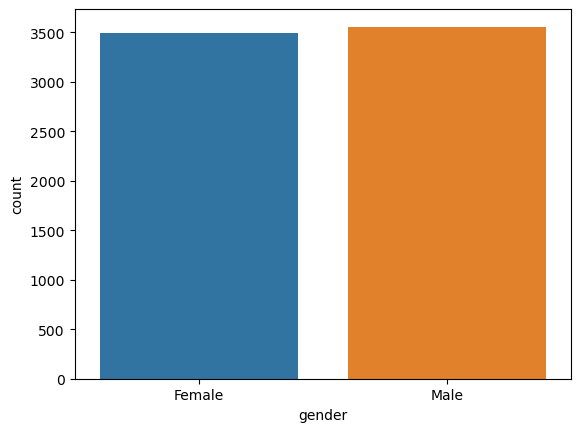

In [18]:
sns.countplot(data=df, x="gender", hue="gender")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [20]:
cat_list = df.select_dtypes(include="object").columns
for column in cat_list:
    print(df[column].value_counts(normalize=True).round(3))
    print("------")

gender
Male      0.505
Female    0.495
Name: proportion, dtype: float64
------
Partner
No     0.517
Yes    0.483
Name: proportion, dtype: float64
------
Dependents
No     0.7
Yes    0.3
Name: proportion, dtype: float64
------
PhoneService
Yes    0.903
No     0.097
Name: proportion, dtype: float64
------
MultipleLines
No                  0.481
Yes                 0.422
No phone service    0.097
Name: proportion, dtype: float64
------
InternetService
Fiber optic    0.440
DSL            0.344
No             0.217
Name: proportion, dtype: float64
------
OnlineSecurity
No                     0.497
Yes                    0.287
No internet service    0.217
Name: proportion, dtype: float64
------
OnlineBackup
No                     0.438
Yes                    0.345
No internet service    0.217
Name: proportion, dtype: float64
------
DeviceProtection
No                     0.439
Yes                    0.344
No internet service    0.217
Name: proportion, dtype: float64
------
TechSupport
No    

#### Numerical Variables

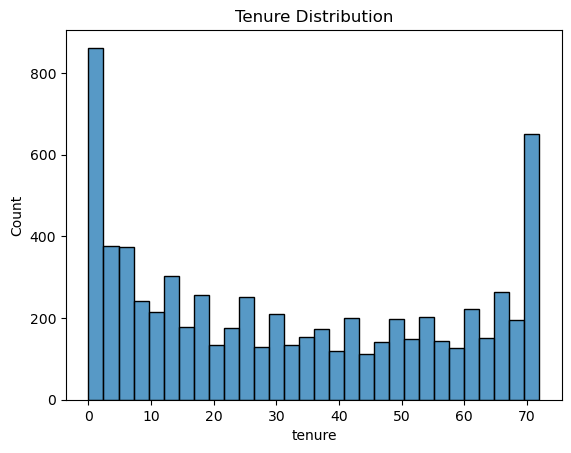

In [21]:
sns.histplot(data=df, x="tenure", bins=30)
plt.title("Tenure Distribution");

In [22]:
df.tenure.value_counts().sort_index(ascending=False)

tenure
72    362
71    170
70    119
69     95
68    100
     ... 
4     176
3     200
2     238
1     613
0      11
Name: count, Length: 73, dtype: int64

Tenure values of 1 and 72 are significantly higher than other values.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

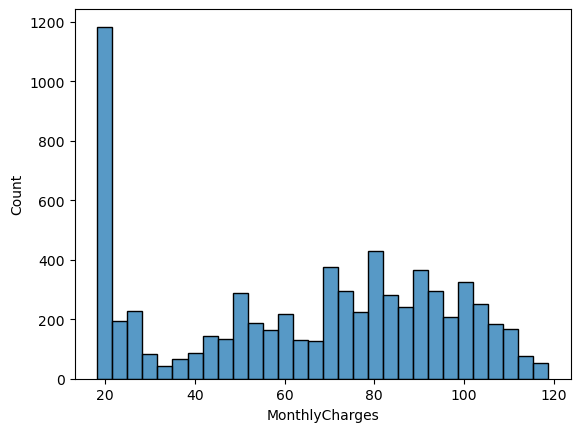

In [23]:
sns.histplot(data=df, x="MonthlyCharges", bins=30)

In [24]:
df.MonthlyCharges.value_counts().sort_values(ascending=False)

MonthlyCharges
20.05    61
19.85    45
19.95    44
19.90    44
20.00    43
         ..
82.40     1
56.00     1
26.50     1
40.90     1
78.70     1
Name: count, Length: 1585, dtype: int64

<Axes: xlabel='TotalCharges', ylabel='Count'>

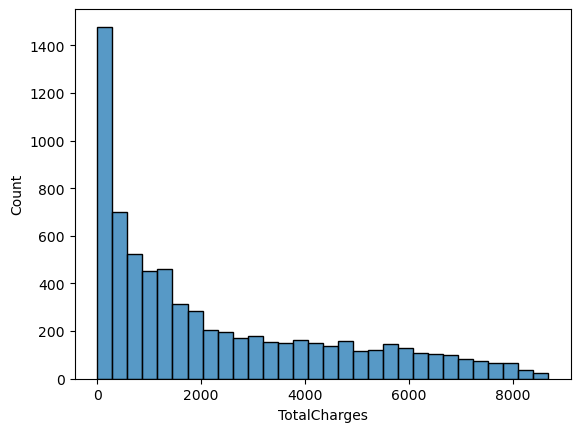

In [25]:
sns.histplot(data=df, x="TotalCharges", bins=30)

To do list:
- Change variable types to correct types
- Make "No internet service" values just "No" (Since we have "InternetService" variable, there will be no information loss)
- Target value distribution is around 73%-26%. Try both with and without target oversampling

## Bivariate Analysis

In [26]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


#### Categorical Variables

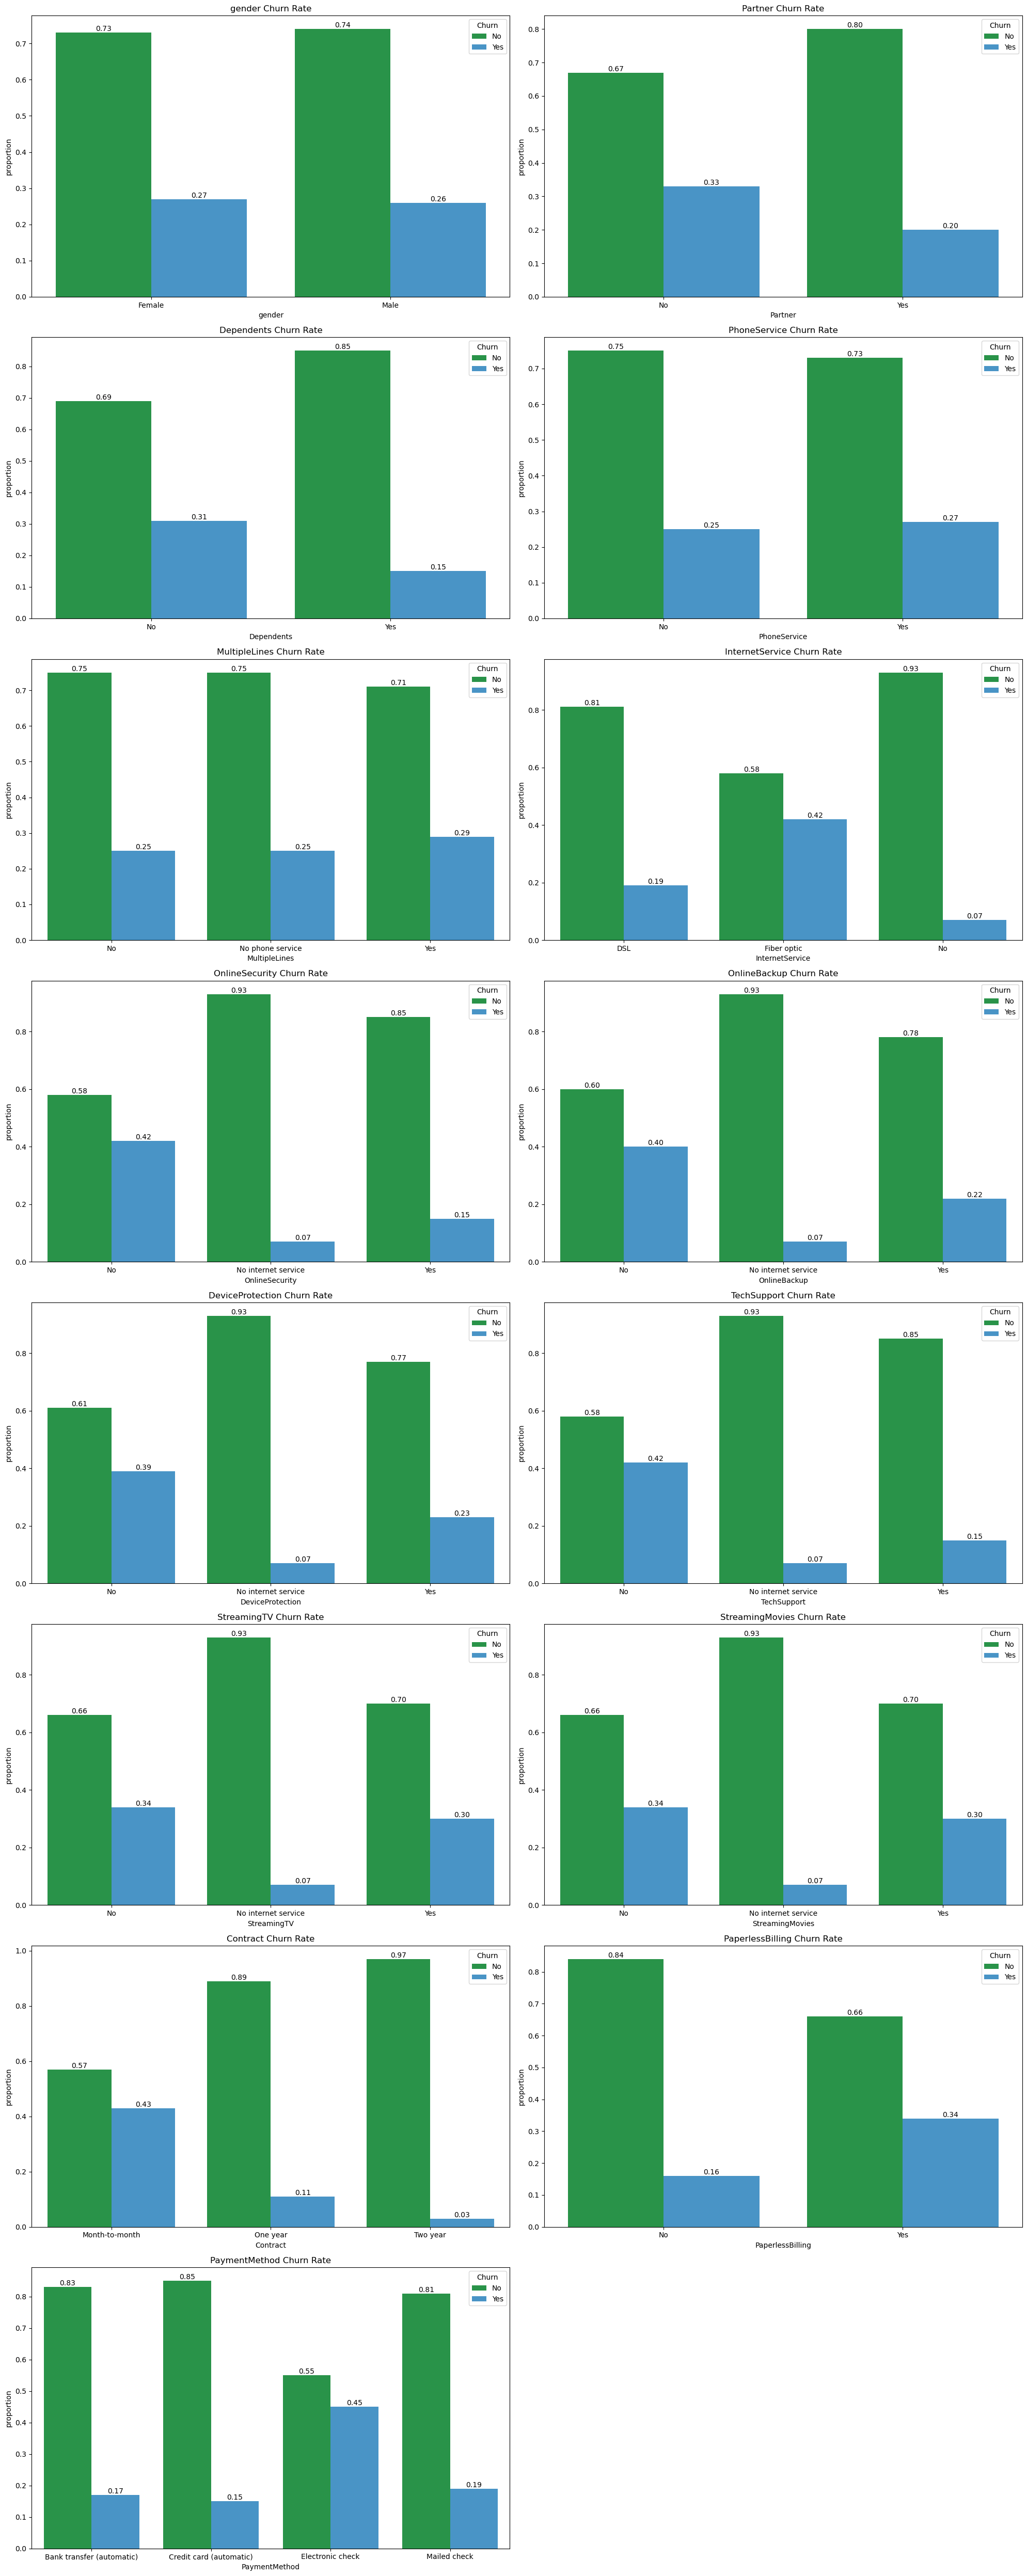

In [27]:
fig, axes = plt.subplots(int(len(cat_list)/2), 2, figsize=(20,50))
axes = axes.flatten()

for i, column in enumerate(cat_list[:-1]):
    churn_rate = df.groupby(f"{column}")["Churn"].value_counts(normalize=True).round(2).reset_index()
    sns.barplot(data=churn_rate, x=f"{column}", y="proportion", hue="Churn", ax=axes[i], palette=["#18A442", "#3498db"])
    axes[i].set_title(f"{column} Churn Rate")

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.2f") # Writing proportions on bars

axes[-1].set_visible(False)
plt.tight_layout()

Notes:
- Customers without a partner churn at a higher rate.
- Customers without dependents churn at a higher rate.
- Fiber optic users churn at a significantly higher rate.
- Customers without OnlineSecurity churn at a high rate, while those with it churn at a much lower rate.
- Month-to-month contract holders churn at a significantly higher rate compared to those with committed contracts.
- Customers receiving paper bills churn less compared to those with electronic billing.
- Customers paying by electronic check churn at by far the highest rate.

Although Fiber optic service is more premium, their users have been churned at a higher rate. \
We will analyse it deeper to find whether the service quality or service fee is the main problem.

In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


In [29]:
df[df.Contract == "Month-to-month"].groupby("Contract")["InternetService"].value_counts(normalize=True).round(2).reset_index()

,Contract,InternetService,proportion
0,Month-to-month,Fiber optic,0.55
1,Month-to-month,DSL,0.32
2,Month-to-month,No,0.14


Proportion of the Month-to-month customers that uses Fiber optic is high, \
but that does not explain all the reasons behind fiber optic users has a higher churn rate.

C:\Users\Ozi\AppData\Local\Temp\ipykernel_22464\4162520632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="InternetService", y="MonthlyCharges", palette=["#2D19E6","#E8E005","#E61C19"])


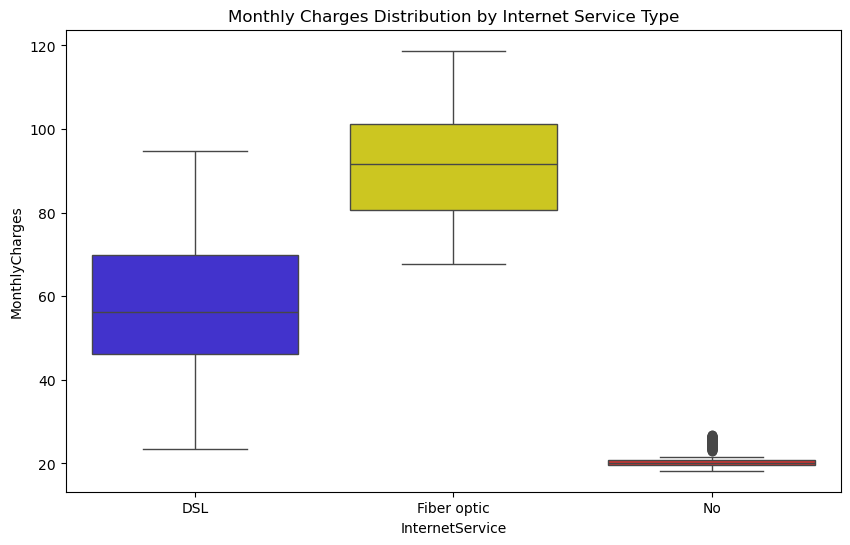

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="InternetService", y="MonthlyCharges", palette=["#2D19E6","#E8E005","#E61C19"])
plt.title("Monthly Charges Distribution by Internet Service Type");

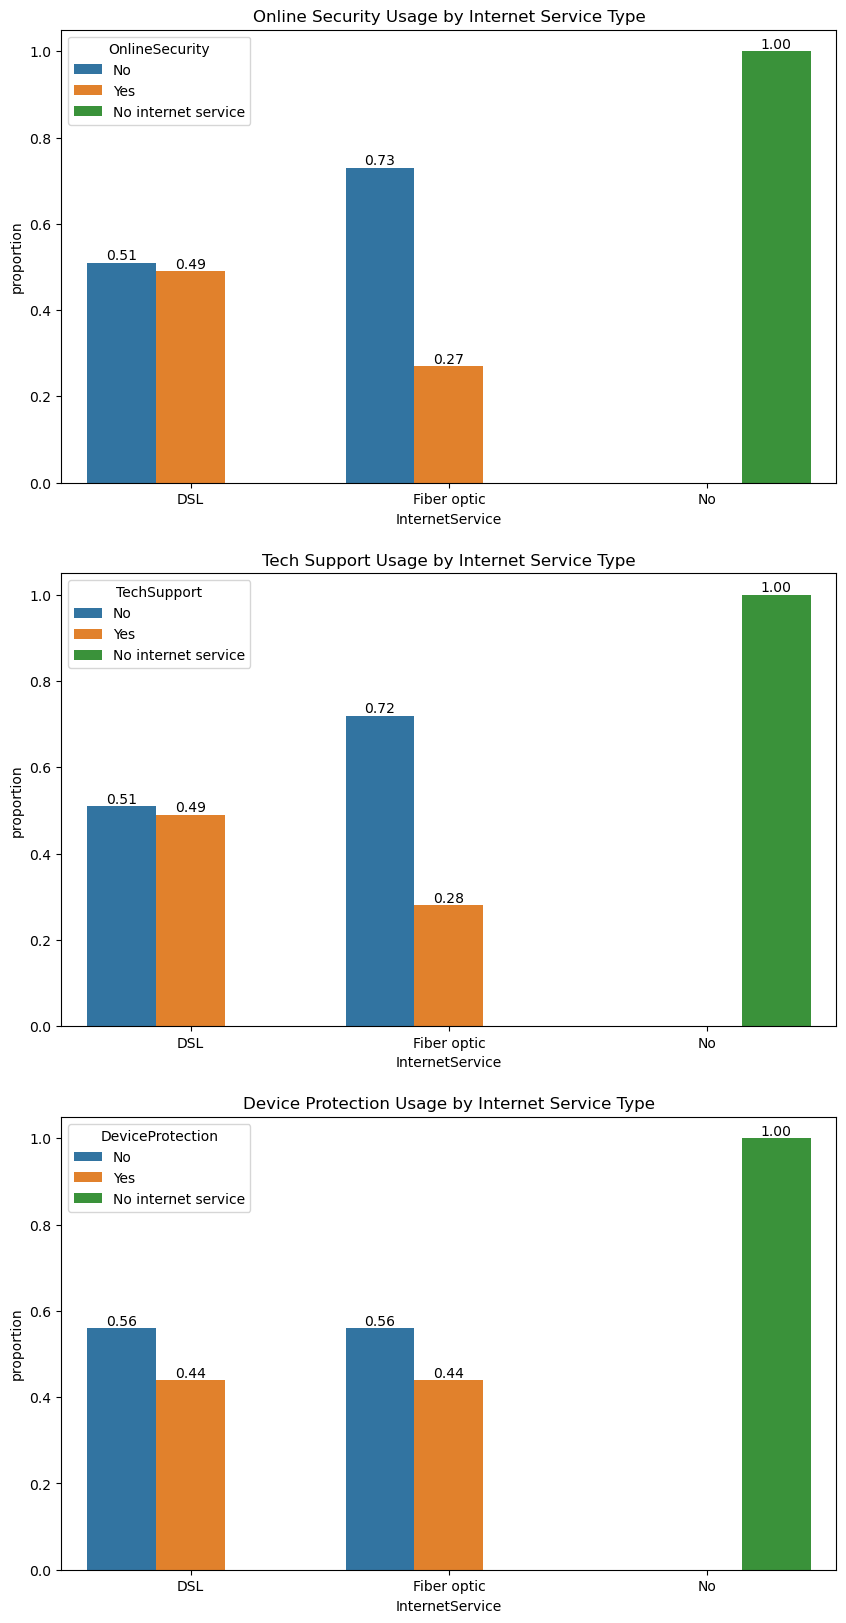

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(10,20))

sns.barplot(data=df.groupby("InternetService")["OnlineSecurity"].value_counts(normalize=True).round(2).reset_index(),
            x="InternetService", y="proportion", hue="OnlineSecurity", ax=axes[0])
axes[0].set_title("Online Security Usage by Internet Service Type")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f")

sns.barplot(data=df.groupby("InternetService")["TechSupport"].value_counts(normalize=True).round(2).reset_index(),
            x="InternetService", y="proportion", hue="TechSupport", ax=axes[1])
axes[1].set_title("Tech Support Usage by Internet Service Type")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f")

sns.barplot(data=df.groupby("InternetService")["DeviceProtection"].value_counts(normalize=True).round(2).reset_index(),
            x="InternetService", y="proportion", hue="DeviceProtection", ax=axes[2])
axes[2].set_title("Device Protection Usage by Internet Service Type")

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.2f");

Since additional services like TechSupport and OnlineSecurity are free, \
fiber optic users' lower uptake of these services suggests fewer technical issues, \
pointing to a pricing concern rather than a service quality problem.

#### Numerical Variables

In [32]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


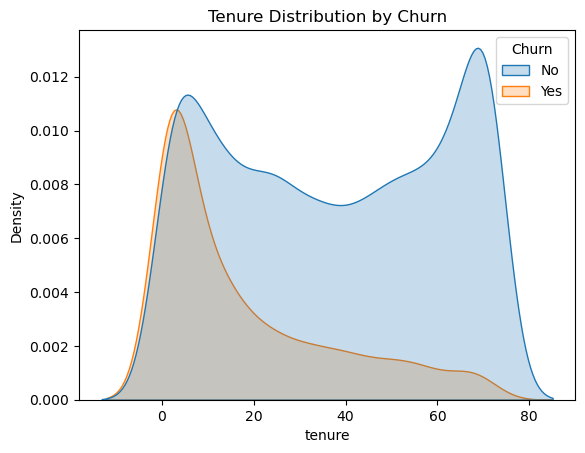

In [33]:
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True)
plt.title("Tenure Distribution by Churn");

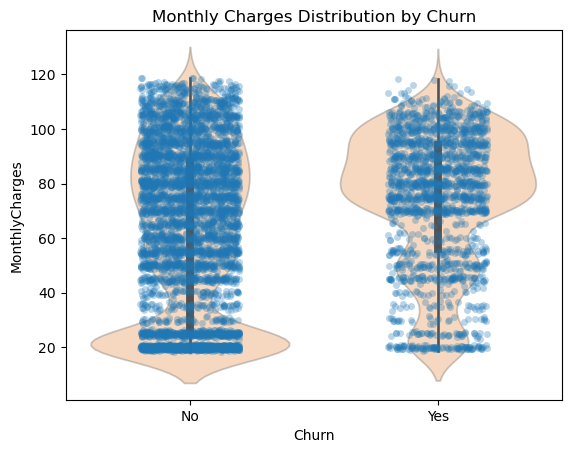

In [34]:
sns.stripplot(data=df, x="Churn", y="MonthlyCharges", alpha=0.3, jitter=0.2, size=5)
sns.violinplot(data=df, x="Churn", y="MonthlyCharges", alpha=0.3)
plt.title("Monthly Charges Distribution by Churn");

Customers who churned tend to have high monthly charges.

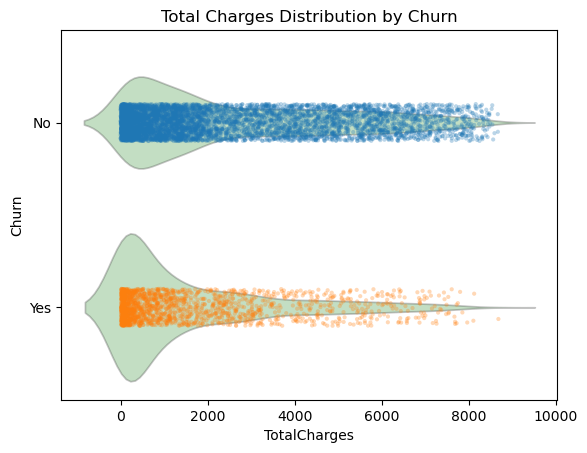

In [35]:
sns.stripplot(data=df, x="TotalCharges", y="Churn", alpha=0.3, size=3, hue="Churn")
sns.violinplot(data=df, x="TotalCharges", y="Churn", alpha=0.3, inner=None)
plt.title("Total Charges Distribution by Churn");

To do list:
- Discretization of tenure variable can be considered

## Feature Engineering

In [36]:
df_raw = df # Don't run this again

In [37]:
df = df_raw.copy() # Run this instead

In [38]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


#### Changing "No internet-phone service" value with "No"

In [39]:
df.MultipleLines.value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [40]:
df.loc[df.MultipleLines == "No phone service", "MultipleLines"] = "No"

In [41]:
df.MultipleLines.value_counts()

MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

In [42]:
df.loc[df.OnlineSecurity == "No internet service", "OnlineSecurity"] = "No"
df.loc[df.OnlineBackup == "No internet service", "OnlineBackup"] = "No"
df.loc[df.DeviceProtection == "No internet service", "DeviceProtection"] = "No"
df.loc[df.TechSupport == "No internet service", "TechSupport"] = "No"
df.loc[df.StreamingTV == "No internet service", "StreamingTV"] = "No"
df.loc[df.StreamingMovies == "No internet service", "StreamingMovies"] = "No"


#### Total Service Taken

##### Feature Engineering Functions

The implementations of the custom transformers are located in **feature_engineering.py** and are  
imported here to ensure they are shared consistently between model training and deployment.

In [43]:
# total_service implementation

# def total_service (X):
#     service_cols = X.loc[:,"PhoneService":"StreamingMovies"].columns
#     X["TotalServices"] = X[service_cols].apply(lambda x: len(service_cols) - sum(v == "No" for v in x), axis=1) 
#     return X
# 
# Counts the number of services taken by subtracting "No" responses from total number of service columns

In [44]:
# total_service_transformer = FunctionTransformer(total_service) 
# Creates a new column with the number of total service taken

#### Changing "Yes", "No" values to 1,0 Integers

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [46]:
# gender_binary implementation
#
# def gender_binary (X):
#     X = X.copy()
#     X["gender"] = X["gender"].map({"Male":1, "Female":0})
#     return X

In [47]:
# binary_transform implementation

# def binary_transform (X):
#     X = X.copy()
#     binary_cols = ["Partner", "Dependents", "PhoneService", "MultipleLines",
#                "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", 
#                "StreamingTV", "StreamingMovies", "PaperlessBilling"]
#     for col in binary_cols:
#         X[col] = X[col].map({"Yes":1, "No":0})
#     return X

Without `X = X.copy()`, the function modifies the original DataFrame in-place. \
When the transformer is called again, the values are already 0/1 instead of "Yes"/"No", \
so `.map({"Yes":1, "No":0})` returns NaN for all values.

In [48]:
# gender_binary_transformer = FunctionTransformer(gender_binary) # Transforms only "Gender" column to binary
# yes_no_transformer = FunctionTransformer(binary_transform) # Transforms all "Yes-No" values of according columns to binary

In [49]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


#### Train-Test-Split

In [50]:
df_engineered = df.copy() # Don't run this again

In [51]:
df = df_engineered.copy() # Run this instead

In [52]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [53]:
y = y.map({"Yes":1, "No":0})
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
joblib.dump(X_train, "X_train.pkl") # This part is for streamlit

#### Preprocessing

In [56]:
feature_eng_pipeline = Pipeline(steps=[("total_service", total_service_transformer),
                                       ("gender", gender_binary_transformer),
                                       ("yes_no", yes_no_transformer)]).set_output(transform="pandas")

In [57]:
feature_eng_pipeline.fit_transform(X_train).isnull().sum()


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
TotalServices       0
dtype: int64

In [58]:
ordinal_column = ["Contract"]
OHE_columns = ["InternetService", "PaymentMethod"]
num_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

In [59]:
OHE_pipeline = Pipeline(steps=[("one-hot_encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
ordinal_pipeline = Pipeline(steps=[("label_encoding", OrdinalEncoder(categories=[["Month-to-month", "One year", "Two year"]]))])
num_pipeline = Pipeline(steps=[("scaling", MinMaxScaler())])

In [60]:
ct = ColumnTransformer(transformers=[("OHE", OHE_pipeline, OHE_columns),
                                     ("ordinal", ordinal_pipeline, ordinal_column),
                                     ("numerical", num_pipeline, num_columns)],
                                       remainder="passthrough", verbose_feature_names_out=False).set_output(transform="pandas")

#### Last Analysis Before Calling and Fitting the Model

In [61]:
preprocessing_pipeline = Pipeline(steps=[("feature_engineering", feature_eng_pipeline),
                                         ("preprocessing", ct)]).set_output(transform="pandas")

In [62]:
preprocessing_pipeline

,steps,"[('feature_engineering', ...), ('preprocessing', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('total_service', ...), ('gender', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function tot...002A5322FEA20>
,inverse_func,None
,validate,False


In [63]:
X_transformed = preprocessing_pipeline.fit_transform(X_train)

In [64]:
X_transformed

,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,TotalServices
3738,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.486111,0.306926,0.195877,1,0,0,0,0,0,0,0,1,0,1,1,0,4
3151,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.208333,0.565022,0.132543,1,0,1,1,1,0,1,0,0,0,0,0,0,3
4860,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.180556,0.220727,0.067941,1,0,1,1,0,0,1,1,0,1,0,0,0,4
3867,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.361111,0.549078,0.219369,0,0,1,0,1,0,0,1,1,0,1,1,1,6
3810,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.013889,0.260588,0.005067,1,0,1,1,1,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,0.986111,0.905331,0.887494,0,0,1,0,1,1,0,1,1,1,1,1,0,8
6227,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.027778,0.275536,0.009212,1,0,0,0,1,0,0,0,0,0,0,0,0,2
4673,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.347222,0.841056,0.306310,0,1,0,0,1,1,1,1,0,0,1,1,1,7
2710,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.333333,0.019930,0.055504,0,0,1,0,1,0,0,0,0,0,0,0,0,1


In [65]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'TotalServices'],
      dtype='object')

In [66]:
X_transformed.columns

Index(['InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'TotalServices'],
      dtype='object')

<Axes: >

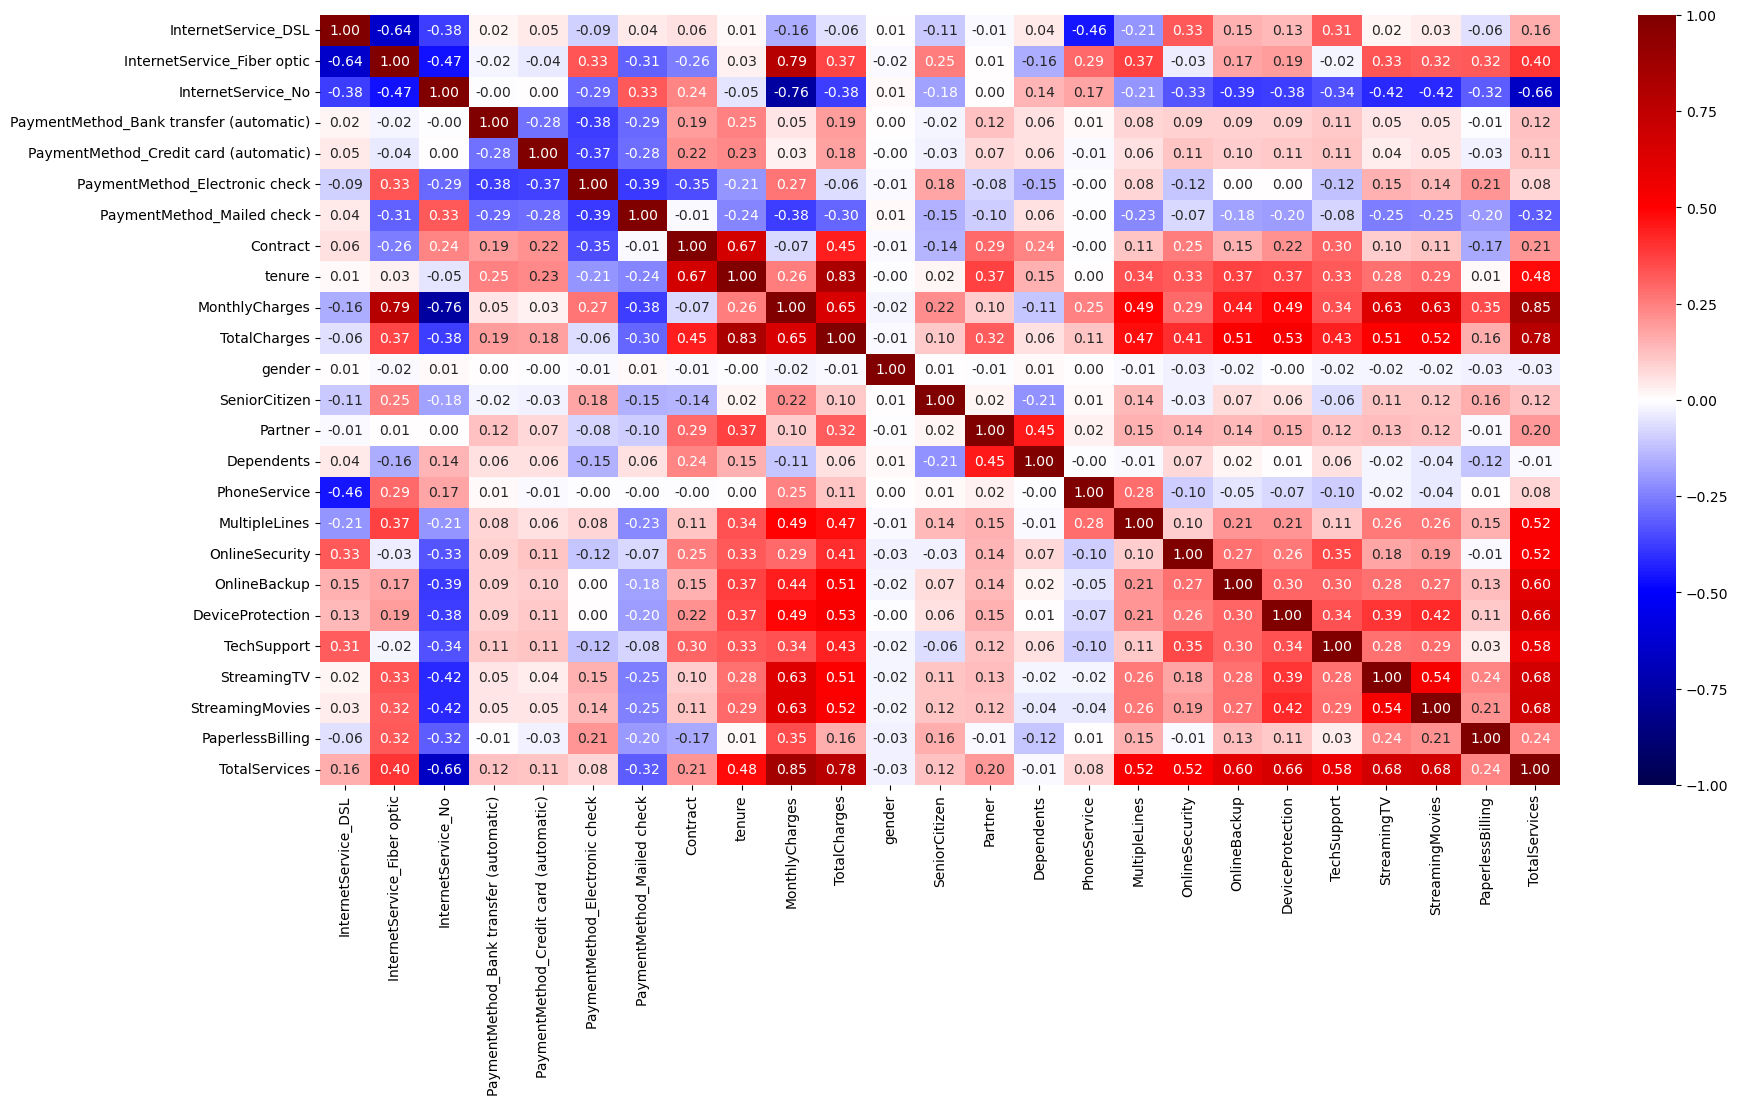

In [67]:
plt.figure(figsize=(20,10))
sns.heatmap(data=X_transformed.corr(), vmax=1, vmin=-1, cmap="seismic", annot=True, fmt=".2f", cbar=True)

Since we will not use linear ML algorithm, we will not have multicollinearity problem.

## Model Selection & Evaluation

In [68]:
logistic_pipeline = Pipeline(steps=[("preprocessing", preprocessing_pipeline),
                                 ("model", LogisticRegression(random_state=42))])
tree_pipeline = Pipeline(steps=[("preprocessing", preprocessing_pipeline),
                                 ("model", DecisionTreeClassifier(random_state=42))])
rf_pipeline = Pipeline(steps=[("preprocessing", preprocessing_pipeline),
                                 ("model", RandomForestClassifier(random_state=42))])
svm_pipeline = Pipeline(steps=[("preprocessing", preprocessing_pipeline),
                                 ("model", SVC(random_state=42))])
xgb_pipeline = Pipeline(steps=[("preprocessing", preprocessing_pipeline),
                                 ("model", XGBClassifier(random_state=42))])
lgbm_pipeline = Pipeline(steps=[("preprocessing", preprocessing_pipeline),
                                 ("model", LGBMClassifier(random_state=42, verbose=-1))])

In [69]:
print(f"Logistic Regression f1 score:{cross_val_score(logistic_pipeline, X_train, y_train, cv=5, scoring='f1').mean().round(3)}") # It automatically uses StratifiedKFold
print(f"Decision Tree f1 score:{cross_val_score(tree_pipeline, X_train, y_train, cv=5, scoring='f1').mean().round(3)}")
print(f"Random Forest f1 score:{cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='f1').mean().round(3)}")
print(f"Support Vector Machine f1 score:{cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring='f1').mean().round(3)}")
print(f"XGBoost f1 score:{cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='f1').mean().round(3)}")
print(f"LightGBM f1 score:{cross_val_score(lgbm_pipeline, X_train, y_train, cv=5, scoring='f1').mean().round(3)}")

Logistic Regression f1 score:0.593
Decision Tree f1 score:0.502
Random Forest f1 score:0.542
Support Vector Machine f1 score:0.553
XGBoost f1 score:0.55
LightGBM f1 score:0.574


Although they are not the highest scoring models, I will tune XGBoost and Random Forest to better understand and practice with them

## Hyperparameter Tuning for XGBoost and Random Forest

#### 1)XGBoost

In [70]:
list(xgb_pipeline.get_params())

['memory',
 'steps',
 'transform_input',
 'verbose',
 'preprocessing',
 'model',
 'preprocessing__memory',
 'preprocessing__steps',
 'preprocessing__transform_input',
 'preprocessing__verbose',
 'preprocessing__feature_engineering',
 'preprocessing__preprocessing',
 'preprocessing__feature_engineering__memory',
 'preprocessing__feature_engineering__steps',
 'preprocessing__feature_engineering__transform_input',
 'preprocessing__feature_engineering__verbose',
 'preprocessing__feature_engineering__total_service',
 'preprocessing__feature_engineering__gender',
 'preprocessing__feature_engineering__yes_no',
 'preprocessing__feature_engineering__total_service__accept_sparse',
 'preprocessing__feature_engineering__total_service__check_inverse',
 'preprocessing__feature_engineering__total_service__feature_names_out',
 'preprocessing__feature_engineering__total_service__func',
 'preprocessing__feature_engineering__total_service__inv_kw_args',
 'preprocessing__feature_engineering__total_service

In [71]:
xgb_param_grid = {"model__n_estimators": [50,100,200,500,1000],
              "model__learning_rate": [0.01, 0.05, 0.1, 0.25, 0.5],
              "model__max_depth": [3, 4, 5, 6, 7],
              "model__min_child_weight": [1, 3, 5, 7, 10],
              "model__gamma": [0, 0.1, 0.2, 0.5, 1],
              "model__colsample_bytree": [0.5, 0.7, 0.8, 0.9, 1],
              "model__reg_lambda": [0.1, 0.5, 1, 2, 5]}

grid_search = RandomizedSearchCV(xgb_pipeline, xgb_param_grid, n_iter=100, cv=5, scoring="f1", n_jobs=-1, verbose=0, random_state=42)

In [ ]:
grid_search.fit(X_train, y_train)

joblib.dump(grid_search, "xgb_grid_search.pkl") # Don't run this again

['xgb_grid_search.pkl']

In [73]:
xgb_grid_search = joblib.load("xgb_grid_search.pkl")

results = pd.DataFrame(xgb_grid_search.cv_results_)
results.sort_values("mean_test_score", ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__reg_lambda,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__gamma,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
54,0.415241,0.071505,0.116730,0.028215,2.0,100,1,4,0.25,1.0,0.8,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.641577,0.585742,0.595506,0.574545,0.566176,0.592709,0.026376,1
48,0.432231,0.078601,0.104093,0.029862,1.0,100,7,3,0.05,0.1,0.7,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.626866,0.584615,0.596226,0.571956,0.564486,0.588830,0.021893,2
59,0.410238,0.048923,0.102118,0.006689,0.5,100,10,3,0.10,0.0,0.8,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.641026,0.571429,0.593985,0.573503,0.561468,0.588282,0.028411,3
76,2.304651,0.356098,0.122072,0.020614,5.0,1000,1,4,0.01,0.5,0.8,"{'model__reg_lambda': 5, 'model__n_estimators'...",0.634234,0.596958,0.595104,0.560440,0.551471,0.587641,0.029535,4
57,1.790774,0.179389,0.149629,0.048189,1.0,1000,5,3,0.01,0.1,1.0,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.636364,0.588462,0.593985,0.571429,0.547486,0.587545,0.029292,5
50,0.471923,0.042267,0.090279,0.006969,5.0,200,5,5,0.25,1.0,1.0,"{'model__reg_lambda': 5, 'model__n_estimators'...",0.634409,0.591603,0.592871,0.563071,0.554128,0.587216,0.028129,6
21,0.507133,0.052949,0.113389,0.027489,2.0,100,3,3,0.05,0.5,0.7,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.631970,0.579655,0.592453,0.570902,0.557009,0.586398,0.025545,7
28,0.586889,0.049023,0.103776,0.025279,0.5,200,1,3,0.05,0.5,0.9,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.633700,0.573099,0.603416,0.569343,0.549815,0.585875,0.029434,8
98,1.152711,0.061492,0.094323,0.009082,2.0,1000,10,6,0.25,1.0,1.0,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.637523,0.575238,0.596226,0.564486,0.555147,0.585724,0.029289,9
85,0.491323,0.063429,0.092626,0.015784,0.5,200,10,4,0.10,1.0,0.5,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.641304,0.580153,0.584440,0.554529,0.567219,0.585529,0.029790,10


I will zoom in on Best scoring models parameters.

In [74]:
xgb_param_grid_2 = {"model__reg_lambda" : [1,2,3],
              "model__n_estimators": [50,100,150],
              "model__max_depth": [3,4,5],
              "model__learning_rate": [0.15,0.25,0.35],
              "model__gamma": [1,1.5,2],
              "model__colsample_bytree": [0.7,0.8,0.9]}

grid_search_2 = GridSearchCV(xgb_pipeline, xgb_param_grid_2, cv=5, scoring="f1", n_jobs=-1, verbose=0)

In [ ]:
grid_search_2.fit(X_train, y_train)

joblib.dump(grid_search_2, "xgb_grid_search_2.pkl") # Don't run this again

['xgb_grid_search_2.pkl']

In [76]:
xgb_grid_search_2 = joblib.load("xgb_grid_search_2.pkl")

results_2 = pd.DataFrame(xgb_grid_search_2.cv_results_)
results_2.sort_values("mean_test_score", ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__colsample_bytree,param_model__gamma,param_model__learning_rate,param_model__max_depth,param_model__n_estimators,param_model__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
116,0.320752,0.013237,0.081823,0.005118,0.7,1.5,0.25,3,150,3,"{'model__colsample_bytree': 0.7, 'model__gamma...",0.632163,0.588008,0.610487,0.581481,0.570902,0.596608,0.022001,1
113,0.260727,0.006732,0.069063,0.003874,0.7,1.5,0.25,3,100,3,"{'model__colsample_bytree': 0.7, 'model__gamma...",0.632163,0.588008,0.610487,0.581481,0.570902,0.596608,0.022001,1
110,0.243371,0.007402,0.084048,0.005510,0.7,1.5,0.25,3,50,3,"{'model__colsample_bytree': 0.7, 'model__gamma...",0.632163,0.588008,0.610487,0.581481,0.570902,0.596608,0.022001,1
600,0.269974,0.005962,0.072562,0.003730,0.9,1.5,0.25,3,150,1,"{'model__colsample_bytree': 0.9, 'model__gamma...",0.637363,0.580392,0.607076,0.575045,0.576710,0.595317,0.024025,4
597,0.225336,0.007045,0.066159,0.005055,0.9,1.5,0.25,3,100,1,"{'model__colsample_bytree': 0.9, 'model__gamma...",0.637363,0.580392,0.607076,0.575045,0.576710,0.595317,0.024025,4
594,0.241528,0.025933,0.068126,0.003777,0.9,1.5,0.25,3,50,1,"{'model__colsample_bytree': 0.9, 'model__gamma...",0.637363,0.580392,0.607076,0.575045,0.576710,0.595317,0.024025,4
251,0.341328,0.020758,0.083554,0.015499,0.8,1.0,0.15,3,150,3,"{'model__colsample_bytree': 0.8, 'model__gamma...",0.636029,0.595420,0.612782,0.571949,0.555556,0.594347,0.028583,7
248,0.259290,0.006301,0.071377,0.006124,0.8,1.0,0.15,3,100,3,"{'model__colsample_bytree': 0.8, 'model__gamma...",0.636029,0.595420,0.612782,0.571949,0.555556,0.594347,0.028583,7
108,0.292341,0.013406,0.092113,0.013625,0.7,1.5,0.25,3,50,1,"{'model__colsample_bytree': 0.7, 'model__gamma...",0.638686,0.586408,0.603774,0.571429,0.571429,0.594345,0.025173,9
114,0.286810,0.014089,0.067209,0.001755,0.7,1.5,0.25,3,150,1,"{'model__colsample_bytree': 0.7, 'model__gamma...",0.638686,0.586408,0.603774,0.571429,0.571429,0.594345,0.025173,9


By zooming in, we improved our score by 0.004

In [77]:
xgb_grid_search_2.best_params_

{'model__colsample_bytree': 0.7,
 'model__gamma': 1.5,
 'model__learning_rate': 0.25,
 'model__max_depth': 3,
 'model__n_estimators': 50,
 'model__reg_lambda': 3}

Since we have only around 7000 instances, setting `n_estimators`=`100` is safer.

In [78]:
xgb_grid_search_2.best_params_["model__n_estimators"]=100
xgb_grid_search_2.best_params_

{'model__colsample_bytree': 0.7,
 'model__gamma': 1.5,
 'model__learning_rate': 0.25,
 'model__max_depth': 3,
 'model__n_estimators': 100,
 'model__reg_lambda': 3}

In [79]:
xgb_pipeline.set_params(**xgb_grid_search_2.best_params_)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('feature_engineering', ...), ('preprocessing', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('total_service', ...), ('gender', ...), ...]"
,transform_input,None
,memory,None


#### 2)Random Forest

In [80]:
rf_param_grid = {"model__n_estimators": [100, 200, 300, 500],
                 "model__max_depth": [2, 3, 5, 7, 10],
                 "model__min_samples_split": [2, 5, 10, 20],
                 "model__min_samples_leaf": [1, 2, 4, 8],
                 "model__max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
                 "model__class_weight": [None, "balanced"]}
rf_grid_search = RandomizedSearchCV(rf_pipeline, rf_param_grid, n_iter=300, cv=5, scoring="f1", verbose=0, n_jobs=-1, random_state=42)

In [ ]:
rf_grid_search.fit(X_train, y_train)

joblib.dump(rf_grid_search, "rf_grid_search.pkl") # Don't run this again

['rf_grid_search.pkl']

In [82]:
rf_grid_search = joblib.load("rf_grid_search.pkl")

rf_results = pd.DataFrame(rf_grid_search.cv_results_).sort_values("mean_test_score", ascending=False).head(10)
rf_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,param_model__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
23,5.043740,0.498609,0.222945,0.020272,500,20,1,sqrt,10,balanced,"{'model__n_estimators': 500, 'model__min_sampl...",0.647145,0.658824,0.646288,0.647482,0.603043,0.640556,0.019314,1
150,1.015245,0.070579,0.097197,0.009815,100,2,8,sqrt,10,balanced,"{'model__n_estimators': 100, 'model__min_sampl...",0.654339,0.653295,0.642959,0.645980,0.605653,0.640445,0.017920,2
145,6.496020,0.251981,0.183781,0.028736,500,5,8,0.5,7,balanced,"{'model__n_estimators': 500, 'model__min_sampl...",0.650636,0.641457,0.645341,0.654646,0.608466,0.640109,0.016448,3
221,4.207883,0.324562,0.136454,0.015319,300,10,1,0.5,7,balanced,"{'model__n_estimators': 300, 'model__min_sampl...",0.649351,0.643059,0.646976,0.659280,0.596817,0.639097,0.021808,4
114,3.128136,0.540749,0.188389,0.057354,300,2,8,sqrt,10,balanced,"{'model__n_estimators': 300, 'model__min_sampl...",0.650360,0.650360,0.639321,0.649718,0.602442,0.638440,0.018482,5
191,3.148418,0.278930,0.109403,0.014873,200,20,8,0.7,7,balanced,"{'model__n_estimators': 200, 'model__min_sampl...",0.646809,0.638655,0.636872,0.659341,0.610080,0.638351,0.016209,6
161,2.534685,0.245889,0.133611,0.011703,300,5,8,log2,10,balanced,"{'model__n_estimators': 300, 'model__min_sampl...",0.650430,0.653465,0.634831,0.644068,0.606142,0.637787,0.017060,7
134,6.697191,0.363391,0.182366,0.013505,500,20,2,0.5,7,balanced,"{'model__n_estimators': 500, 'model__min_sampl...",0.647564,0.637640,0.642356,0.653793,0.607190,0.637709,0.016179,8
6,4.531620,0.240575,0.143133,0.008009,300,10,2,0.5,7,balanced,"{'model__n_estimators': 300, 'model__min_sampl...",0.648415,0.640339,0.645980,0.656467,0.597094,0.637659,0.020935,9
44,0.966937,0.036626,0.100911,0.017802,100,10,2,log2,10,balanced,"{'model__n_estimators': 100, 'model__min_sampl...",0.644118,0.658789,0.641509,0.640466,0.603306,0.637637,0.018390,10


Compared to XGBoost, Random Forest performed significantly better, improving the F1 score by ~7%. This is mainly due to the `class_weight` parameter that \
handles class imbalance. As we can see, all top 10 RF models have `class_weight='balanced'`. What if we had not used this parameter?

In [83]:
rf_grid_search.best_params_["model__class_weight"] = None
rf_grid_search.best_params_

{'model__n_estimators': 500,
 'model__min_samples_split': 20,
 'model__min_samples_leaf': 1,
 'model__max_features': 'sqrt',
 'model__max_depth': 10,
 'model__class_weight': None}

In [84]:
rf_pipeline.set_params(**rf_grid_search.best_params_)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('feature_engineering', ...), ('preprocessing', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('total_service', ...), ('gender', ...), ...]"
,transform_input,None
,memory,None


In [85]:
cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring="f1").mean().round(3)

np.float64(0.566)

Without `class_weight='balanced'`, the F1 score drops from 0.640 to 0.566. Significant decrease of ~7%. \
This confirms that handling class imbalance through `class_weight` is crucial for this dataset.

## Oversampling

#### Deciding if Oversampling is Needed

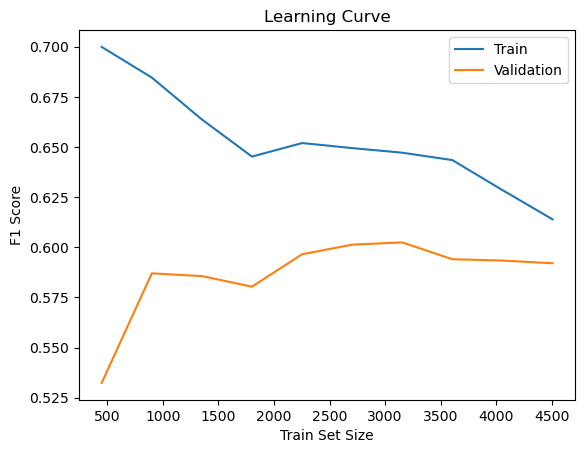

<Figure size 1000x800 with 0 Axes>

In [86]:
train_sizes, train_scores, val_scores = learning_curve(xgb_pipeline, X_train, y_train, cv=5, random_state=42,
                                                       train_sizes=np.linspace(0.1, 1, 10), scoring="f1")

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.xlabel("Train Set Size")
plt.ylabel("F1 Score")
plt.figure(figsize=(10,8));

The training score decreases as data grows, indicating the model is generalizing rather than memorizing. \
Validation score plateaus around 0.60 after ~2,500 samples, suggesting additional data or oversampling is unlikely to make improvement. \
I will experiment with SMOTE and class_weight adjustments anyways to validate this assumption.

#### SMOTE

In [87]:
X_smoted_try, y_smoted_try = SMOTE(random_state=42).fit_resample(X_transformed, y_train)

print(pd.Series(y_smoted_try).value_counts())
print(pd.Series(y_train.value_counts()))

Churn
0    4139
1    4139
Name: count, dtype: int64
Churn
0    4139
1    1495
Name: count, dtype: int64


Doing oversampling manually would lead to a data leakage since we don't want our synthetic data to be in our validation sets. \
Thus we must use `imblearn.Pipeline`

In [88]:
xgb_smote_pipeline = ImbPipeline(steps=[("feature_engineering", feature_eng_pipeline),
                                        ("preprocessing", ct),
                                        ("oversampling", SMOTE(random_state=42)),
                                        ("model", XGBClassifier(random_state=42))]).set_output(transform="pandas")

Somehow `imblearn.Pipeline` does not accept any other `Pipeline` in it's steps.  
So unwrapping `feature_eng_pipeline` should work.

In [89]:
xgb_smote_pipeline = ImbPipeline(steps=[("total_service", total_service_transformer),
                                        ("gender", gender_binary_transformer),
                                        ("yes_no", yes_no_transformer),
                                        ("preprocessing", ct),
                                        ("oversampling", SMOTE(random_state=42)),
                                        ("model", XGBClassifier(random_state=42))]).set_output(transform="pandas")

In [90]:
xgb_param_grid

{'model__n_estimators': [50, 100, 200, 500, 1000],
 'model__learning_rate': [0.01, 0.05, 0.1, 0.25, 0.5],
 'model__max_depth': [3, 4, 5, 6, 7],
 'model__min_child_weight': [1, 3, 5, 7, 10],
 'model__gamma': [0, 0.1, 0.2, 0.5, 1],
 'model__colsample_bytree': [0.5, 0.7, 0.8, 0.9, 1],
 'model__reg_lambda': [0.1, 0.5, 1, 2, 5]}

In [91]:
xgb_smote_grid_search = RandomizedSearchCV(xgb_smote_pipeline, xgb_param_grid, n_iter=100, scoring="f1", verbose=0, random_state=42, n_jobs=-1) # cv=5 is default value

In [ ]:
xgb_smote_grid_search.fit(X_train, y_train)

joblib.dump(xgb_smote_grid_search, "xgb_smote_grid_search.pkl") # Don't run this again

['xgb_smote_grid_search.pkl']

In [93]:
xgb_smote_grid_search = joblib.load("xgb_smote_grid_search.pkl")

xgb_results = pd.DataFrame(xgb_smote_grid_search.cv_results_).sort_values("mean_test_score", ascending=False).head(10)
xgb_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__reg_lambda,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__gamma,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
53,1.606521,0.115720,0.107434,0.011725,1.0,500,5,5,0.01,0.5,0.5,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.649351,0.642755,0.635057,0.641026,0.612859,0.636210,0.012532,1
30,0.548904,0.032711,0.088818,0.019148,0.5,50,5,5,0.01,0.0,0.8,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.652661,0.632597,0.644979,0.651475,0.598693,0.636081,0.020005,2
48,0.461284,0.017452,0.105333,0.020705,1.0,100,7,3,0.05,0.1,0.7,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.652720,0.640884,0.641873,0.635262,0.607235,0.635595,0.015265,3
21,0.580242,0.070109,0.100282,0.013444,2.0,100,3,3,0.05,0.5,0.7,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.649860,0.644537,0.642857,0.630872,0.604651,0.634555,0.016190,4
99,0.704724,0.052466,0.069942,0.015425,0.1,200,7,4,0.05,0.0,1.0,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.647230,0.641399,0.643172,0.627168,0.613037,0.634401,0.012643,5
89,0.978757,0.037209,0.091261,0.008030,0.5,200,5,6,0.01,0.1,0.5,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.647646,0.638298,0.624642,0.645070,0.612466,0.633624,0.013250,6
28,0.743583,0.076812,0.098327,0.021889,0.5,200,1,3,0.05,0.5,0.9,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.645441,0.642150,0.640449,0.626741,0.613119,0.633580,0.012056,7
87,1.361103,0.080360,0.089778,0.005543,0.5,500,3,4,0.01,1.0,0.5,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.650289,0.639205,0.635461,0.629834,0.612517,0.633461,0.012426,8
4,1.298906,0.092228,0.111499,0.018835,0.1,500,1,3,0.01,0.2,0.5,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.656338,0.640884,0.641667,0.627876,0.598446,0.633042,0.019505,9
13,0.915546,0.072147,0.088563,0.009002,0.1,200,10,5,0.01,1.0,0.9,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.646409,0.644809,0.635461,0.631579,0.605020,0.632655,0.014897,10


Our f1 score has improved by 4% compared to the XGBoost model without oversampling

In [94]:
xgb_smote_grid_search.best_params_

{'model__reg_lambda': 1,
 'model__n_estimators': 500,
 'model__min_child_weight': 5,
 'model__max_depth': 5,
 'model__learning_rate': 0.01,
 'model__gamma': 0.5,
 'model__colsample_bytree': 0.5}

In [95]:
xgb_smote_pipeline = xgb_smote_grid_search.best_estimator_

In [96]:
results_table = xgb_results.iloc[0,-3:-1].astype(float).round(3).to_frame().T.rename(index={53: "XGB_SMOTE"}) # Getting results for final comparison
results_table

,mean_test_score,std_test_score
XGB_SMOTE,0.636,0.013


In [97]:
rf_smote_pipeline = ImbPipeline(steps=[("total_service", total_service_transformer),
                                        ("gender", gender_binary_transformer),
                                        ("yes_no", yes_no_transformer),
                                        ("preprocessing", ct),
                                        ("oversampling", SMOTE(random_state=42)),
                                        ("model", RandomForestClassifier(random_state=42))]).set_output(transform="pandas")

In [98]:
rf_param_grid = {'model__n_estimators': [100, 200, 300, 500],
                 'model__max_depth': [2, 3, 5, 7, 10],
                 'model__min_samples_split': [2, 5, 10, 20],
                 'model__min_samples_leaf': [1, 2, 4, 8],
                 'model__max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
                 'model__class_weight': [None]} # Forcing not to use `class_weight`

In [99]:
rf_smote_grid_search = RandomizedSearchCV(rf_smote_pipeline, rf_param_grid, n_iter=100, cv=5, n_jobs=-1, scoring="f1", verbose=0, random_state=42)

In [ ]:
rf_smote_grid_search.fit(X_train, y_train)

joblib.dump(rf_smote_grid_search, "rf_smote_grid_search.pkl") # Don't run this again

['rf_smote_grid_search.pkl']

In [101]:
rf_smote_grid_search = joblib.load("rf_smote_grid_search.pkl")

rf_results = pd.DataFrame(rf_smote_grid_search.cv_results_).sort_values("mean_test_score", ascending=False).head(10)
rf_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,param_model__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
77,2.308173,0.242617,0.132802,0.008043,200,2,8,log2,7,None,"{'model__n_estimators': 200, 'model__min_sampl...",0.653631,0.643646,0.647059,0.642077,0.603381,0.637959,0.017739,1
35,5.500178,0.200847,0.217116,0.020076,500,20,8,log2,7,None,"{'model__n_estimators': 500, 'model__min_sampl...",0.657303,0.643646,0.640777,0.641096,0.606771,0.637919,0.016715,2
63,1.220295,0.115380,0.089102,0.010152,100,20,1,log2,7,None,"{'model__n_estimators': 100, 'model__min_sampl...",0.654443,0.644444,0.641457,0.644898,0.602632,0.637575,0.018008,3
90,1.424962,0.087597,0.105604,0.013348,100,20,8,log2,7,None,"{'model__n_estimators': 100, 'model__min_sampl...",0.649789,0.641770,0.645251,0.639456,0.607895,0.636832,0.014882,4
67,3.533713,0.282029,0.150929,0.008626,300,10,8,sqrt,7,None,"{'model__n_estimators': 300, 'model__min_sampl...",0.649718,0.645251,0.637762,0.642857,0.603922,0.635902,0.016449,5
75,5.340784,0.168399,0.199371,0.023206,500,2,2,log2,7,None,"{'model__n_estimators': 500, 'model__min_sampl...",0.654339,0.640884,0.636872,0.637602,0.602883,0.634516,0.017025,6
96,4.272355,0.357507,0.171619,0.037563,500,2,1,log2,5,None,"{'model__n_estimators': 500, 'model__min_sampl...",0.653951,0.637954,0.637483,0.641161,0.601023,0.634314,0.017687,7
32,6.890230,0.467644,0.203904,0.045684,500,10,2,sqrt,7,None,"{'model__n_estimators': 500, 'model__min_sampl...",0.654339,0.636872,0.641457,0.638356,0.600262,0.634257,0.018080,8
25,6.650094,0.531524,0.163282,0.019570,300,5,8,0.5,7,None,"{'model__n_estimators': 300, 'model__min_sampl...",0.651558,0.637640,0.635328,0.644163,0.601064,0.633951,0.017386,9
87,1.261071,0.060988,0.137230,0.030665,100,20,8,log2,5,None,"{'model__n_estimators': 100, 'model__min_sampl...",0.654939,0.636119,0.636856,0.643045,0.597205,0.633633,0.019422,10


F1 score of Random Forest with `class_weight`=`balanced` was 0.640.  
F1 score of Random Forest with `SMOTE` is 0.638.

In [102]:
rf_results.iloc[0, -3:-1].T.rename(index={77: "RF_SMOTE"}).to_list()

[np.float64(0.6379588068643847), np.float64(0.017739023904420212)]

In [103]:
results_table.loc["RF_SMOTE"] = rf_results.iloc[0, -3:-1].astype(float).round(3).T.rename(index={77: "RF_SMOTE"}).to_list()

In [104]:
results_table

,mean_test_score,std_test_score
XGB_SMOTE,0.636,0.013
RF_SMOTE,0.638,0.018


In [105]:
rf_smote_pipeline = rf_smote_grid_search.best_estimator_

#### Class_weight

Instead of treating all misclassifications equally, we weight them by their business cost.
$$\text{scale\_pos\_weight} = \frac{\text{fn\_cost}}{\text{fp\_cost}}$$
Where:

`fn_cost` = average `MonthlyCharges` of churners (Churn=1) — revenue lost if we miss them  
`fp_cost` = average `MonthlyCharges` of non-churners (Churn=0) × campaign rate — money wasted on unnecessary retention offers

Each CV fold has a slightly different class distribution and charge profile.  
Computing per-fold prevents leakage and makes the cost ratio reflect the actual training data the model sees.



In [106]:
class DynamicWeight(BaseEstimator, TransformerMixin):
    
    def __init__(self, xgb_model, campaign_rate=0.20): # Average campaign rate for a telco company is around 20%
        self.xgb_model = xgb_model
        self.campaign_rate = campaign_rate

    def fit(self, X, y=None):
        self.fn_cost = X.loc[y[y==1].index, "MonthlyCharges"].mean()
        self.fp_cost = X.loc[y[y==0].index, "MonthlyCharges"].mean() * self.campaign_rate
        self.xgb_model.set_params(scale_pos_weight = self.fn_cost/self.fp_cost)
        return self
    
    def transform(self, X):
        return X # Since we don't want to change anything from X

In [107]:
model = XGBClassifier(random_state=42)

xgb_weighted_pipeline = Pipeline(steps=[("feature_engineering", feature_eng_pipeline),
                                        ("preprocessing", ct),
                                        ("dynamic_weight", DynamicWeight(xgb_model=model)),
                                        ("model", model)])

In [108]:
xgb_weighted_grid_search = RandomizedSearchCV(xgb_weighted_pipeline, xgb_param_grid, cv=5, scoring="f1", n_iter=100, n_jobs=1, random_state=42)

In [ ]:
xgb_weighted_grid_search.fit(X_train, y_train)

joblib.dump(xgb_weighted_grid_search, "xgb_weighted_grid_search_2.pkl") # Don't run this again

['xgb_weighted_grid_search_2.pkl']

In [110]:
xgb_weighted_grid_search_2 = joblib.load("xgb_weighted_grid_search_2.pkl")

xgb_results = pd.DataFrame(xgb_weighted_grid_search_2.cv_results_).sort_values("mean_test_score", ascending=False).head(10)
xgb_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__reg_lambda,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__gamma,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
54,0.196690,0.037539,0.065589,0.027209,2.0,100,1,4,0.25,1.0,0.8,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.641577,0.585742,0.595506,0.574545,0.566176,0.592709,0.026376,1
48,0.163120,0.001744,0.047661,0.000860,1.0,100,7,3,0.05,0.1,0.7,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.626866,0.584615,0.596226,0.571956,0.564486,0.588830,0.021893,2
59,0.172703,0.002833,0.049260,0.000687,0.5,100,10,3,0.10,0.0,0.8,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.641026,0.571429,0.593985,0.573503,0.561468,0.588282,0.028411,3
76,0.696169,0.013246,0.050754,0.000553,5.0,1000,1,4,0.01,0.5,0.8,"{'model__reg_lambda': 5, 'model__n_estimators'...",0.634234,0.596958,0.595104,0.560440,0.551471,0.587641,0.029535,4
57,0.653203,0.020470,0.051178,0.001173,1.0,1000,5,3,0.01,0.1,1.0,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.636364,0.588462,0.593985,0.571429,0.547486,0.587545,0.029292,5
50,0.199809,0.003373,0.048407,0.000294,5.0,200,5,5,0.25,1.0,1.0,"{'model__reg_lambda': 5, 'model__n_estimators'...",0.634409,0.591603,0.592871,0.563071,0.554128,0.587216,0.028129,6
21,0.163836,0.001059,0.047688,0.000607,2.0,100,3,3,0.05,0.5,0.7,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.631970,0.579655,0.592453,0.570902,0.557009,0.586398,0.025545,7
28,0.219822,0.001431,0.048239,0.000271,0.5,200,1,3,0.05,0.5,0.9,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.633700,0.573099,0.603416,0.569343,0.549815,0.585875,0.029434,8
98,0.469720,0.004396,0.049754,0.001017,2.0,1000,10,6,0.25,1.0,1.0,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.637523,0.575238,0.596226,0.564486,0.555147,0.585724,0.029289,9
85,0.196291,0.000967,0.047837,0.000640,0.5,200,10,4,0.10,1.0,0.5,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.641304,0.580153,0.584440,0.554529,0.567219,0.585529,0.029790,10


`RandomizedSearchCV` somehow could not set `XGBClassifier` `scale_pos_weight` parameter, giving the grid search results of `scale_pos_weight`=`None` models.  
To solve the issue, I will create a custom predictor instead of custom transformer.

In [111]:
class CostSensitiveXGB(XGBClassifier):
    
    def __init__(self, campaign_rate=0.20, **kwargs):

        super().__init__(**kwargs)
        self.campaign_rate = campaign_rate

    def fit(self, X, y, **kwargs):

        fn_cost = X.loc[y[y==1].index, "MonthlyCharges"].mean()
        fp_cost = X.loc[y[y==0].index, "MonthlyCharges"].mean()*self.campaign_rate
        self.set_params(scale_pos_weight = fn_cost/fp_cost)

        return super().fit(X, y, **kwargs)

In [112]:
xgb_weighted_pipeline = Pipeline(steps=[("preprocessing", preprocessing_pipeline),
                                        ("model", CostSensitiveXGB(random_state=42))])

In [113]:
xgb_weighted_grid_search = RandomizedSearchCV(xgb_weighted_pipeline, xgb_param_grid, cv=5, scoring="f1", n_iter=100, n_jobs=-1, random_state=42)

In [ ]:
xgb_weighted_grid_search.fit(X_train, y_train)

joblib.dump(xgb_weighted_grid_search, "xgb_weighted_grid_search.pkl") # Don't run this again

c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:31] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


['xgb_weighted_grid_search.pkl']

In [115]:
xgb_weighted_grid_search = joblib.load("xgb_weighted_grid_search.pkl")

xgb_results = pd.DataFrame(xgb_weighted_grid_search.cv_results_).sort_values("mean_test_score", ascending=False).head(10)
xgb_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__reg_lambda,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__gamma,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
88,0.709049,0.026975,0.087547,0.012087,0.1,200,3,7,0.05,0.2,0.8,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.613665,0.628057,0.623077,0.598226,0.598742,0.612353,0.012232,1
8,2.995246,0.108298,0.173597,0.023756,2.0,1000,1,6,0.01,0.0,0.7,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.623188,0.616125,0.617466,0.598558,0.605701,0.612208,0.008857,2
73,0.824606,0.048151,0.108999,0.015406,5.0,200,7,7,0.05,0.1,0.9,"{'model__reg_lambda': 5, 'model__n_estimators'...",0.617433,0.619684,0.608374,0.599269,0.603819,0.609716,0.007806,3
43,0.418627,0.025842,0.089798,0.009415,0.1,100,5,6,0.10,0.0,0.9,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.620606,0.615764,0.610837,0.593037,0.608076,0.609664,0.009352,4
3,0.743373,0.067391,0.112210,0.028934,0.5,200,1,7,0.10,0.2,0.9,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.619946,0.627815,0.601604,0.594452,0.603922,0.609548,0.012365,5
97,1.467709,0.048513,0.078098,0.013080,1.0,1000,7,4,0.05,0.1,0.8,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.617612,0.611043,0.604768,0.616915,0.597340,0.609536,0.007661,6
16,0.934621,0.050369,0.088135,0.005178,5.0,500,7,6,0.25,0.1,1.0,"{'model__reg_lambda': 5, 'model__n_estimators'...",0.617992,0.627660,0.596538,0.601604,0.601307,0.609020,0.011817,7
46,1.380976,0.067019,0.100432,0.010124,0.5,1000,10,4,0.10,0.1,1.0,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.606280,0.619403,0.596713,0.616561,0.606061,0.609003,0.008153,8
95,0.424045,0.040855,0.076295,0.011085,0.1,200,3,7,0.25,1.0,0.7,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.603015,0.643127,0.611180,0.596319,0.591304,0.608989,0.018326,9
63,0.841101,0.019519,0.102643,0.008075,0.5,500,7,7,0.25,0.2,0.9,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.606138,0.626943,0.616385,0.597641,0.596977,0.608817,0.011472,10


As we can observe, we improved our best f1 score by 2%

In [116]:
xgb_weighted_pipeline = xgb_weighted_grid_search.best_estimator_

In [117]:
results_table.loc["XGB_Weighted"] = xgb_results.iloc[0, -3:-1].astype(float).round(3).T.to_list()
results_table

,mean_test_score,std_test_score
XGB_SMOTE,0.636,0.013
RF_SMOTE,0.638,0.018
XGB_Weighted,0.612,0.012


In [118]:
y_preds = xgb_weighted_pipeline.predict(X_train)
confusion_matrix(y_train, y_preds)

array([[3181,  958],
       [   0, 1495]])

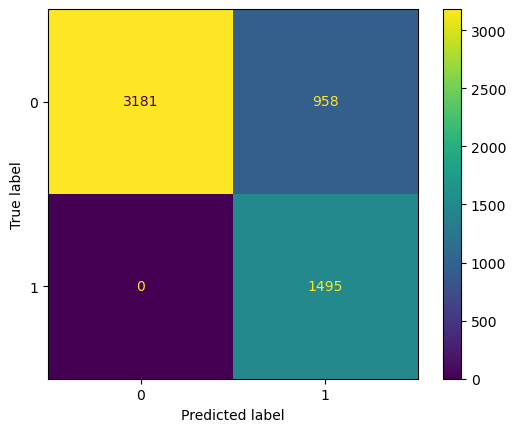

In [119]:
ConfusionMatrixDisplay.from_estimator(xgb_weighted_pipeline, X_train, y_train)

In [120]:
y_preds_cv = cross_val_predict(xgb_weighted_pipeline, X_train, y_train, cv=5)

confusion_matrix(y_train, y_preds_cv)

c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:33] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:33] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:34] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:34] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_17774103170

array([[2896, 1243],
       [ 287, 1208]])

In [121]:
y_preds_cv = cross_val_predict(xgb_smote_pipeline, X_train, y_train, cv=5)

confusion_matrix(y_train, y_preds_cv)

array([[3235,  904],
       [ 376, 1119]])

As we can see from confusion matrix's, although Oversampling method has higher f1 score, weighted model has higher recall value

#### SMOTE + class_weight

In [122]:
xgb_both_pipeline = ImbPipeline(steps=[("total_service", total_service_transformer),
                                       ("gender", gender_binary_transformer),
                                       ("yes_no", yes_no_transformer),
                                       ("preprocessing", ct),
                                       ("oversampling", SMOTE(random_state=42)),
                                       ("model", CostSensitiveXGB(random_state=42))]).set_output(transform="pandas")

In [123]:
xgb_both_grid_search = RandomizedSearchCV(xgb_both_pipeline, xgb_param_grid, n_iter=100, cv=5, scoring="f1", n_jobs=1, verbose=0, random_state=42)

In [ ]:
xgb_both_grid_search = xgb_both_grid_search.fit(X_train, y_train)

joblib.dump(xgb_both_grid_search, "xgb_both_grid_search.pkl") # Don't run this again

c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:38] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:40] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:41] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:20:42] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_17774103170

['xgb_both_grid_search.pkl']

In [125]:
xgb_both_grid_search = joblib.load("xgb_both_grid_search.pkl")

xgb_results = pd.DataFrame(xgb_both_grid_search.cv_results_).sort_values("mean_test_score", ascending=False).head(10)
xgb_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__reg_lambda,param_model__n_estimators,param_model__min_child_weight,param_model__max_depth,param_model__learning_rate,param_model__gamma,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
63,0.460663,0.008696,0.048863,0.000302,0.5,500,7,7,0.25,0.2,0.9,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.602597,0.625641,0.605020,0.608021,0.577373,0.603730,0.015467,1
3,0.443930,0.020416,0.048911,0.000654,0.5,200,1,7,0.10,0.2,0.9,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.605195,0.615979,0.617571,0.590038,0.588235,0.603404,0.012416,2
62,0.683687,0.033755,0.050718,0.000449,0.5,500,1,6,0.05,0.0,0.5,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.600246,0.604709,0.613065,0.593789,0.602410,0.602844,0.006275,3
10,1.004005,0.040016,0.052280,0.001134,0.5,1000,7,5,0.10,0.1,1.0,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.612658,0.607692,0.611702,0.598179,0.583979,0.602842,0.010732,4
26,0.975253,0.056958,0.052281,0.001205,2.0,1000,1,4,0.10,0.1,0.8,"{'model__reg_lambda': 2, 'model__n_estimators'...",0.613065,0.605296,0.606061,0.604010,0.585732,0.602833,0.009111,5
27,0.430919,0.025908,0.048673,0.000720,0.1,200,5,7,0.10,0.1,1.0,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.617722,0.611940,0.604534,0.590286,0.589091,0.602715,0.011434,6
16,0.634686,0.108524,0.051416,0.004139,5.0,500,7,6,0.25,0.1,1.0,"{'model__reg_lambda': 5, 'model__n_estimators'...",0.610169,0.606061,0.615180,0.606142,0.574866,0.602484,0.014207,7
40,0.652242,0.016346,0.051036,0.001026,1.0,1000,1,4,0.25,0.2,0.7,"{'model__reg_lambda': 1, 'model__n_estimators'...",0.608479,0.610340,0.598758,0.605459,0.587515,0.602110,0.008292,8
45,0.983092,0.176143,0.052827,0.003212,0.1,1000,3,5,0.10,0.1,0.8,"{'model__reg_lambda': 0.1, 'model__n_estimator...",0.614610,0.610966,0.608126,0.592105,0.583226,0.601807,0.012059,9
56,0.346664,0.008442,0.049118,0.000855,0.5,200,7,7,0.25,0.2,1.0,"{'model__reg_lambda': 0.5, 'model__n_estimator...",0.603822,0.608696,0.607190,0.597436,0.585242,0.600477,0.008546,10


In [126]:
results_table.loc["XGB_Both"] = xgb_results.iloc[1, -3:-1].astype(float).round(3).to_list()

In [127]:
xgb_both_pipeline = xgb_both_grid_search.best_estimator_

In [128]:
rf_param_grid = {'model__n_estimators': [100, 200, 300, 500],
                 'model__max_depth': [2, 3, 5, 7, 10],
                 'model__min_samples_split': [2, 5, 10, 20],
                 'model__min_samples_leaf': [1, 2, 4, 8],
                 'model__max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
                 'model__class_weight': ["balanced"]} # Forcing to use `class_weight`

In [129]:
rf_both_pipeline = ImbPipeline(steps=[("total_service", total_service_transformer),
                                      ("gender", gender_binary_transformer),
                                      ("yes_no", yes_no_transformer),
                                      ("preprocessing", ct),
                                      ("oversampling", SMOTE(random_state=42)),
                                      ("model", RandomForestClassifier(random_state=42))]).set_output(transform="pandas")

In [130]:
rf_both_grid_search = RandomizedSearchCV(rf_both_pipeline, rf_param_grid, n_iter=100, cv=5, n_jobs=-1, scoring="f1", random_state=42)

In [ ]:
rf_both_grid_search = rf_both_grid_search.fit(X_train, y_train)

joblib.dump(rf_both_grid_search, "rf_both_grid_search.pkl") # Don't run this again

['rf_both_grid_search.pkl']

In [132]:
rf_both_grid_search = joblib.load("rf_both_grid_search.pkl")

rf_results = pd.DataFrame(rf_both_grid_search.cv_results_).sort_values("mean_test_score", ascending=False).head(10)
rf_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,param_model__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
77,2.263251,0.114019,0.141494,0.026264,200,2,8,log2,7,balanced,"{'model__n_estimators': 200, 'model__min_sampl...",0.653631,0.643646,0.647059,0.642077,0.603381,0.637959,0.017739,1
35,5.021311,0.301625,0.192615,0.023975,500,20,8,log2,7,balanced,"{'model__n_estimators': 500, 'model__min_sampl...",0.657303,0.643646,0.640777,0.641096,0.606771,0.637919,0.016715,2
63,0.969527,0.009797,0.071764,0.003110,100,20,1,log2,7,balanced,"{'model__n_estimators': 100, 'model__min_sampl...",0.654443,0.644444,0.641457,0.644898,0.602632,0.637575,0.018008,3
90,1.066776,0.085271,0.085142,0.010184,100,20,8,log2,7,balanced,"{'model__n_estimators': 100, 'model__min_sampl...",0.649789,0.641770,0.645251,0.639456,0.607895,0.636832,0.014882,4
67,3.538129,0.287721,0.137960,0.015716,300,10,8,sqrt,7,balanced,"{'model__n_estimators': 300, 'model__min_sampl...",0.649718,0.645251,0.637762,0.642857,0.603922,0.635902,0.016449,5
75,5.542132,0.258924,0.233948,0.039102,500,2,2,log2,7,balanced,"{'model__n_estimators': 500, 'model__min_sampl...",0.654339,0.640884,0.636872,0.637602,0.602883,0.634516,0.017025,6
96,4.154696,0.262872,0.177128,0.021693,500,2,1,log2,5,balanced,"{'model__n_estimators': 500, 'model__min_sampl...",0.653951,0.637954,0.637483,0.641161,0.601023,0.634314,0.017687,7
32,5.506755,0.399638,0.203465,0.033249,500,10,2,sqrt,7,balanced,"{'model__n_estimators': 500, 'model__min_sampl...",0.654339,0.636872,0.641457,0.638356,0.600262,0.634257,0.018080,8
25,5.663342,0.366097,0.159992,0.036201,300,5,8,0.5,7,balanced,"{'model__n_estimators': 300, 'model__min_sampl...",0.651558,0.637640,0.635328,0.644163,0.601064,0.633951,0.017386,9
87,0.946354,0.077085,0.086783,0.016648,100,20,8,log2,5,balanced,"{'model__n_estimators': 100, 'model__min_sampl...",0.654939,0.636119,0.636856,0.643045,0.597205,0.633633,0.019422,10


In [133]:
rf_both_pipeline = rf_both_grid_search.best_estimator_

In [134]:
results_table.loc["RF_Both"] = rf_results.iloc[0, -3:-1].astype(float).round(3).to_list()
results_table.sort_values("mean_test_score", ascending=False)

,mean_test_score,std_test_score
RF_SMOTE,0.638,0.018
RF_Both,0.638,0.018
XGB_SMOTE,0.636,0.013
XGB_Weighted,0.612,0.012
XGB_Both,0.603,0.012


In [135]:
xgb_grid_search = joblib.load("xgb_grid_search.pkl")

results = pd.DataFrame(xgb_grid_search.cv_results_).sort_values("mean_test_score", ascending=False).head(10)

results_table.loc["XGB"] = results.iloc[0, -3:-1].astype(float).round(3).to_list() # Adding the base models results to the table

results_table.sort_values("mean_test_score", ascending=False)

,mean_test_score,std_test_score
RF_SMOTE,0.638,0.018
RF_Both,0.638,0.018
XGB_SMOTE,0.636,0.013
XGB_Weighted,0.612,0.012
XGB_Both,0.603,0.012
XGB,0.593,0.026


Since our False Negative cost is 6 times the False Positive cost,  
we should compare our models with F-beta score (β ≈ 2.45), which gives recall 6 times more weight than precision.

In [136]:
pipelines = [xgb_pipeline, xgb_smote_pipeline, xgb_weighted_pipeline, 
             xgb_both_pipeline, rf_smote_pipeline, rf_both_pipeline]

pipeline_names = ["XGB", "XGB_SMOTE", "XGB_Weighted", 
                  "XGB_Both", "RF_SMOTE", "RF_Both"]

fbeta_dict = {}

fbeta_scorer = make_scorer(fbeta_score, beta=2.45)

for name, model in zip(pipeline_names, pipelines):
    scores = cross_val_score(model, X_train, y_train, cv=5, n_jobs=1, scoring=fbeta_scorer).mean().round(3)
    fbeta_dict[f"{name}"] = scores

fbeta_dict


c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:28:17] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:28:18] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:28:18] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_1777410317022\work\src\learner.cc:782: 
Parameters: { "campaign_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Ozi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:28:18] WARNING: C:\Users\task_177741010714337\croot\xgboost-split_17774103170

{'XGB': np.float64(0.55),
 'XGB_SMOTE': np.float64(0.713),
 'XGB_Weighted': np.float64(0.74),
 'XGB_Both': np.float64(0.718),
 'RF_SMOTE': np.float64(0.732),
 'RF_Both': np.float64(0.732)}

In [137]:
for names, scores in fbeta_dict.items():
    results_table.loc[names, "fbeta_score"] = scores

results_table = results_table.sort_values(["mean_test_score", "fbeta_score"], ascending=False)
results_table

,mean_test_score,std_test_score,fbeta_score
RF_SMOTE,0.638,0.018,0.732
RF_Both,0.638,0.018,0.732
XGB_SMOTE,0.636,0.013,0.713
XGB_Weighted,0.612,0.012,0.740
XGB_Both,0.603,0.012,0.718
XGB,0.593,0.026,0.550


## Model Selection Note

Hyperparameter tuning and model comparison were performed using **F1 score**.

In retrospect, **F-beta score (β ≈ 2.45)** would have been a more appropriate metric, 
since the False Negative cost is approximately **6 times** the False Positive cost in this business context.

However, applying F-beta as a selection criterion at this stage would yield biased results, 
because **XGB_Weighted** was already trained with `scale_pos_weight=6` — 
meaning it was explicitly optimized for this cost ratio, while other models were not. 
This makes a direct F-beta comparison unfair across models.

Therefore, **F1 score is retained as the selection criterion** for consistency, 
and **XGB_SMOTE** is selected as the final model.

#### Threshold Optimization

In [138]:
y_probs = cross_val_predict(xgb_smote_pipeline, X_train, y_train, cv=5, method='predict_proba')[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, y_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = np.max(f1_scores)
recall = recalls[best_idx]
precision = precisions[best_idx]

In [139]:
print("Best F1 score:",best_f1.astype(float).round(3))
print("Best threshold:",best_threshold.astype(float).round(3))
print("Recall score:",recall.astype(float).round(3))
print("Precision score:",precision.astype(float).round(3))

Best F1 score: 0.638
Best threshold: 0.518
Recall score: 0.736
Precision score: 0.562


Since f1 score only improves by 0.2%, I will just use the default 0.5 threshold.

## Final Model Training and Evaluation with Test Set

In [140]:
joblib.dump(xgb_smote_pipeline.fit(X_train, y_train), "xgb_smote_final.pkl")

['xgb_smote_final.pkl']

Our final F1 Score: 0.622
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



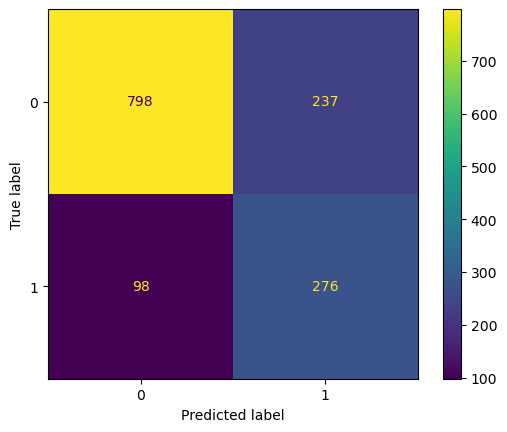

In [141]:
xgb_smote_fitted = joblib.load("xgb_smote_final.pkl")

preds = xgb_smote_fitted.predict(X_test)
score = round(f1_score(y_test, preds),3)

print(f"Our final F1 Score: {score}")
print(classification_report(y_test, preds))

ConfusionMatrixDisplay.from_predictions(y_test, preds)

## Explaining the Predictions

#### Local Explainability

In [142]:
X_test_transformed = Pipeline(xgb_smote_fitted.steps[:-2]).transform(X_test)
X_test_transformed

,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,TotalServices
437,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.000000,0.953164,0.975127,1,0,1,1,1,1,1,1,1,1,1,1,1,9
2280,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.111111,0.814649,0.104560,0,1,0,0,1,1,0,0,0,1,1,1,1,6
2235,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.569444,0.597409,0.369760,0,0,1,1,1,1,1,1,1,0,1,0,1,7
4460,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.250000,0.595914,0.169047,1,0,1,0,1,0,0,0,1,1,0,0,0,4
3761,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.000000,0.640259,0.681598,0,0,1,0,1,1,1,1,1,0,1,1,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.680556,0.685600,0.500345,0,0,1,1,1,0,1,1,1,1,1,1,1,8
4439,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.388889,0.018934,0.056080,1,0,1,1,1,0,0,0,0,0,0,0,1,1
3857,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.069444,0.022422,0.010709,1,0,0,0,1,0,0,0,0,0,0,0,0,1
4758,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.777778,0.012955,0.121027,0,0,0,0,1,0,0,0,0,0,0,0,0,1


In [143]:
shap.initjs()

In [144]:
explainer = shap.Explainer(xgb_smote_fitted.named_steps["model"])
shap_values_classification = explainer(X_test_transformed)

1


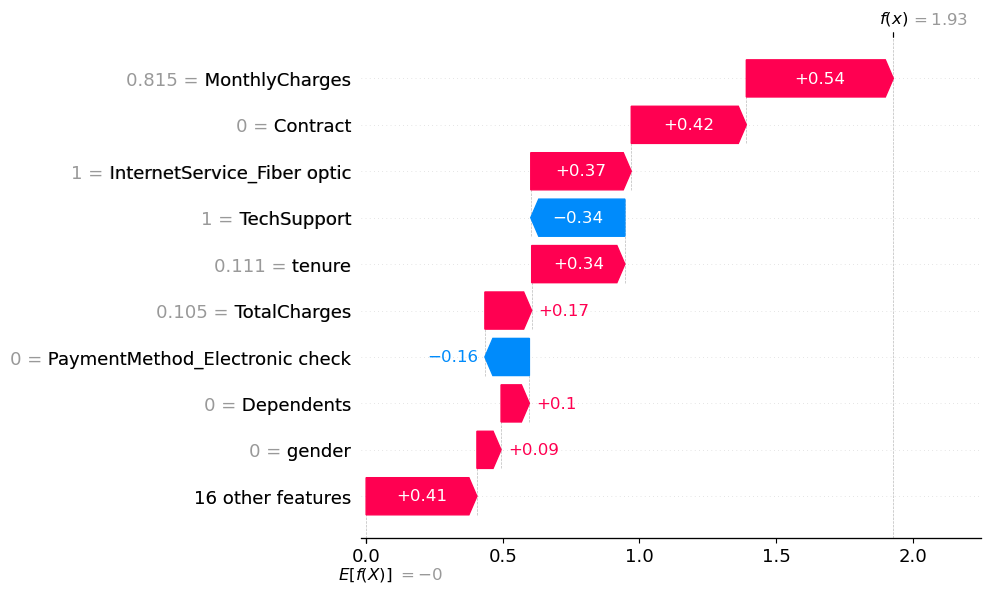

In [145]:
print(preds[1])
shap.plots.waterfall(shap_values_classification[1])

In [146]:
shap.plots.force(shap_values_classification[1])

#### Global Explainability

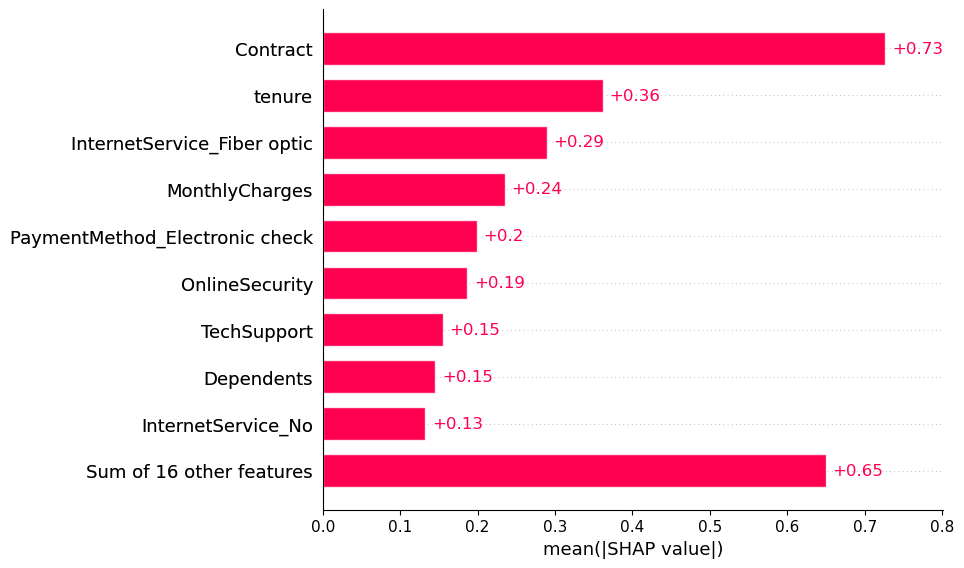

In [147]:
shap.plots.bar(shap_values_classification)

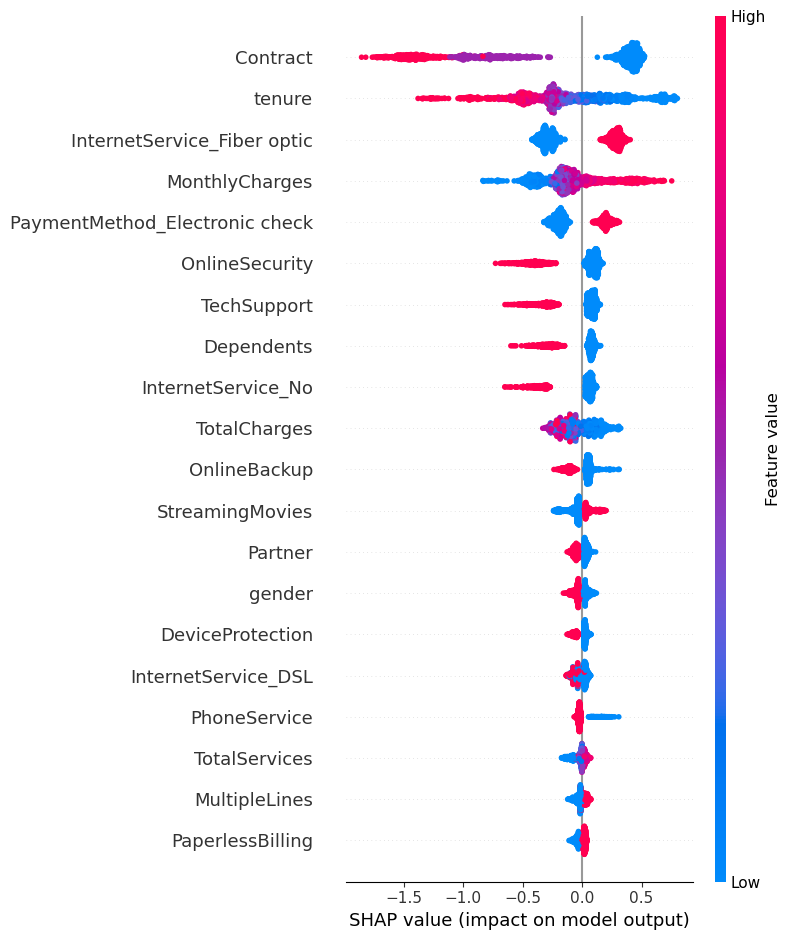

In [148]:
shap.summary_plot(shap_values_classification, X_test_transformed)

As we observed from Exploratory Data Analysis part, most influential features are `Contract`, `tenure`, `InternetService` being `Fiber optic` and `MonthlyCharges`

In [ ]:
streamlit_predict_pipeline = Pipeline(steps=[step for step in xgb_smote_pipeline.steps if step[0] != "oversampling"])

joblib.dump(streamlit_predict_pipeline, "streamlit_predict_pipeline.pkl")

['streamlit_predict_pipeline.pkl']

In [150]:
streamlit_predict_pipeline

,steps,"[('total_service', ...), ('gender', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function tot...002A5322FEA20>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [158]:
print(xgb_pipeline.named_steps.keys())

dict_keys(['preprocessing', 'model'])


In [163]:
xgb_pipeline.named_steps["preprocessing"]["feature_engineering"]["total_service"].func.__module__

'feature_engineering'